# Instant Policy PoC — Generación de Dataset v2

## ¿Qué cambió respecto a v1?

En la versión anterior, el **context** era una copia casi idéntica del **target**
(misma trayectoria con parámetros levemente perturbados + ruido gaussiano).
Esto generaba **fuga de información**: el modelo podía "copiar" el contexto en
vez de aprender a generar trayectorias.

### Nuevo diseño

| Componente | v1 (antes) | v2 (ahora) |
|---|---|---|
| **Context** | ~100 puntos (trayectoria perturbada) | ~5-10 puntos clave (waypoints sparse) |
| **Target (action)** | ~100 puntos (trayectoria limpia) | ~100 puntos (trayectoria limpia) |
| **Relación** | Context ≈ Target | Context ⊂ Target (subconjunto sparse) |

El contexto ahora representa **puntos de referencia de la escena** (inicio, fin,
waypoints intermedios) que le dicen al modelo **qué trayectoria generar**, sin
revelar *cómo* es la trayectoria completa.

Esto obliga al modelo de difusión a aprender verdaderamente a **generar**
trayectorias suaves condicionadas a información sparse.

In [1]:
from src.classes.trajectory_generator import TrajectoryGenerator
import h5py
import numpy as np
import matplotlib.pyplot as plt

## 1. Diseño del Context

El contexto se construye extrayendo **puntos clave equiespaciados** de la
trayectoria target. Siempre incluye el punto inicial y final, más algunos
puntos intermedios.

Parámetros:
- `n_context_points`: cuántos puntos de referencia extraer (default: 8).
  Más puntos → más información → tarea más fácil para el modelo.
  Menos puntos → menos información → mayor capacidad de generalización.

Adicionalmente, se añade un **ruido posicional leve** a los waypoints de
contexto para que el modelo no memorice posiciones exactas y generalice mejor.

In [2]:
def extract_context_waypoints(
    trajectory: np.ndarray,
    n_context_points: int = 8,
    noise_std: float = 0.02,
) -> np.ndarray:
    """
    Extrae waypoints clave de una trayectoria para usar como nodos de contexto.

    Estrategia:
      1. Selecciona `n_context_points` índices equiespaciados a lo largo de la
         trayectoria (siempre incluyendo el primer y último punto).
      2. Añade un pequeño ruido gaussiano para promover la generalización.

    Args:
        trajectory:        array (N, 2) con la trayectoria completa.
        n_context_points:  número de puntos de referencia a extraer.
        noise_std:         desviación estándar del ruido posicional.

    Returns:
        array (n_context_points, 2) con los waypoints de contexto.
    """
    n_total = len(trajectory)
    # Asegurar que no pedimos más puntos de los que hay
    n_context_points = min(n_context_points, n_total)

    # Índices equiespaciados que siempre incluyen el primero y el último
    indices = np.linspace(0, n_total - 1, n_context_points, dtype=int)

    # Extraer los puntos seleccionados
    waypoints = trajectory[indices].copy().astype(np.float32)

    # Añadir ruido posicional leve (excepto al primer y último punto,
    # para que inicio y fin sean más "firmes" como restricciones)
    if noise_std > 0 and n_context_points > 2:
        noise = np.random.normal(0, noise_std, size=waypoints[1:-1].shape)
        waypoints[1:-1] += noise.astype(np.float32)

    return waypoints

## 2. Crear pares (context, target)

Cada par consiste en:
- **target**: la trayectoria completa (N puntos) generada con parámetros aleatorios.
- **context**: un subconjunto sparse de ~8 puntos clave extraídos del target.

In [3]:
def create_demo_pair(
    generator_fn,
    params: dict,
    n_points: int,
    n_context_points: int = 8,
    context_noise_std: float = 0.02,
):
    """
    Crea el par (context, target) para entrenamiento.

    - target:  trayectoria completa (n_points, 2) generada con los params dados.
    - context: waypoints sparse (n_context_points, 2) extraídos del target.

    Args:
        generator_fn:       método estático del TrajectoryGenerator.
        params:             diccionario de parámetros para el generador.
        n_points:           número de puntos en la trayectoria completa.
        n_context_points:   número de waypoints de contexto.
        context_noise_std:  ruido posicional en los waypoints.

    Returns:
        tuple (context, target) como arrays float32.
    """
    target = generator_fn(n_points=n_points, **params).astype(np.float32)
    context = extract_context_waypoints(
        target,
        n_context_points=n_context_points,
        noise_std=context_noise_std
    )
    return context, target

## 3. Tipos de trayectorias

Mismos generadores que v1, con parametrización aleatoria.
Se mantienen solo curvas abiertas y continuas para simplificar la PoC.

In [4]:
def get_trajectory_types(n_points):
    """Devuelve la lista de generadores aleatorios parametrizados."""
    return [
        ("linear", TrajectoryGenerator.linear, dict(
            start=(np.random.uniform(-1, 1), np.random.uniform(-1, 1)),
            angle=np.random.uniform(0, 360),
            length=np.random.uniform(0.5, 2.0)
        )),
        ("parabolic", TrajectoryGenerator.parabolic, dict(
            a=np.random.uniform(-2.0, 2.0),
            h=np.random.uniform(-1.0, 1.0),
            k=np.random.uniform(-1.0, 1.0)
        )),
        ("sigmoid", TrajectoryGenerator.sigmoid, dict(
            L=np.random.uniform(0.5, 2.0),
            k=np.random.uniform(5, 15),
            x0=np.random.uniform(0.5, 1.5)
        )),
        # ("sinusoidal", TrajectoryGenerator.sinusoidal, dict(
        #     amp=np.random.uniform(0.1, 1.0),
        #     freq=np.random.uniform(0.5, 3.0),
        #     phase=np.random.uniform(0, 2 * np.pi)
        # )),
    ]

## 4. Orquestador: generar y guardar el dataset

Genera `n_per_type` pares por cada tipo de trayectoria y los almacena en HDF5.

**Estructura del HDF5:**
```
data/
  demo_0/
    context: (n_context_points, 2)
    target:  (n_points, 2)
    attrs: {type, num_target_points, num_context_points}
  demo_1/
    ...
```

Notar que ahora `context` y `target` tienen **distinta cantidad de puntos**.
Esto es correcto y necesario: el grafo heterogéneo manejará tipos de nodos
con diferente cardinalidad.

In [5]:
def orchestrator(
    file_name: str,
    n_per_type: int = 100,
    n_points: int = 100,
    n_context_points: int = 8,
    context_noise_std: float = 0.02,
):
    """Orquestador principal para generar y guardar el dataset v2."""

    with h5py.File(file_name, 'w') as f:
        data_group = f.create_group("data")
        demo_idx = 0

        for _ in range(n_per_type):
            for name, fn, params in get_trajectory_types(n_points):
                ctx, tgt = create_demo_pair(
                    fn, params, n_points,
                    n_context_points=n_context_points,
                    context_noise_std=context_noise_std
                )

                demo_grp = data_group.create_group(f"demo_{demo_idx}")
                demo_grp.create_dataset("context", data=ctx)
                demo_grp.create_dataset("target",  data=tgt)

                # Metadatos
                demo_grp.attrs["type"]               = name
                demo_grp.attrs["num_target_points"]   = n_points
                demo_grp.attrs["num_context_points"]  = n_context_points

                demo_idx += 1

        # Atributos globales
        f.attrs["total_demos"]       = demo_idx
        f.attrs["n_target_points"]   = n_points
        f.attrs["n_context_points"]  = n_context_points

    print(f"Dataset guardado en '{file_name}' con {demo_idx} demos.")
    print(f"  - Puntos target:  {n_points}")
    print(f"  - Puntos context: {n_context_points}")

## 5. Generar el dataset

In [9]:
FILENAME = "dataset_instant_policy_2d_v2.h5"
N_EXAMPLES = 1000        # demos por tipo de trayectoria
N_POINTS   = 100        # puntos en la trayectoria target
N_CONTEXT  = 8          # waypoints de contexto
CTX_NOISE  = 0.005       # ruido posicional en waypoints

orchestrator(
    FILENAME,
    n_per_type=N_EXAMPLES,
    n_points=N_POINTS,
    n_context_points=N_CONTEXT,
    context_noise_std=CTX_NOISE
)

Dataset guardado en 'dataset_instant_policy_2d_v2.h5' con 3000 demos.
  - Puntos target:  100
  - Puntos context: 8


## 6. Visualización

Verificamos que los pares context/target se ven correctos:
- **Línea negra**: trayectoria target completa.
- **Puntos rojos**: waypoints de contexto (sparse).

Los puntos rojos deben estar *sobre* la trayectoria (o muy cerca),
pero ser muchos menos que los puntos de la trayectoria completa.

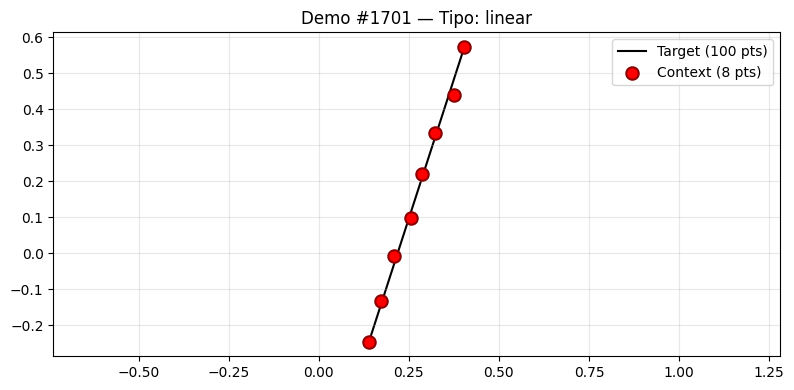

Shape context: (8, 2)
Shape target:  (100, 2)


In [10]:
with h5py.File(FILENAME, 'r') as f:
    n = f.attrs['total_demos']
    idx = np.random.randint(0, n)
    d = f[f'data/demo_{idx}']
    
    ctx = d['context'][:]
    tgt = d['target'][:]
    traj_type = d.attrs['type']
    
    plt.figure(figsize=(8, 4))
    plt.plot(tgt[:, 0], tgt[:, 1], 'k-', linewidth=1.5, label=f'Target ({len(tgt)} pts)', zorder=1)
    plt.scatter(ctx[:, 0], ctx[:, 1], c='red', s=80, zorder=2,
                edgecolors='darkred', linewidths=1.5, label=f'Context ({len(ctx)} pts)')
    plt.title(f"Demo #{idx} — Tipo: {traj_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    print(f"Shape context: {ctx.shape}")
    print(f"Shape target:  {tgt.shape}")

### Visualización de múltiples ejemplos

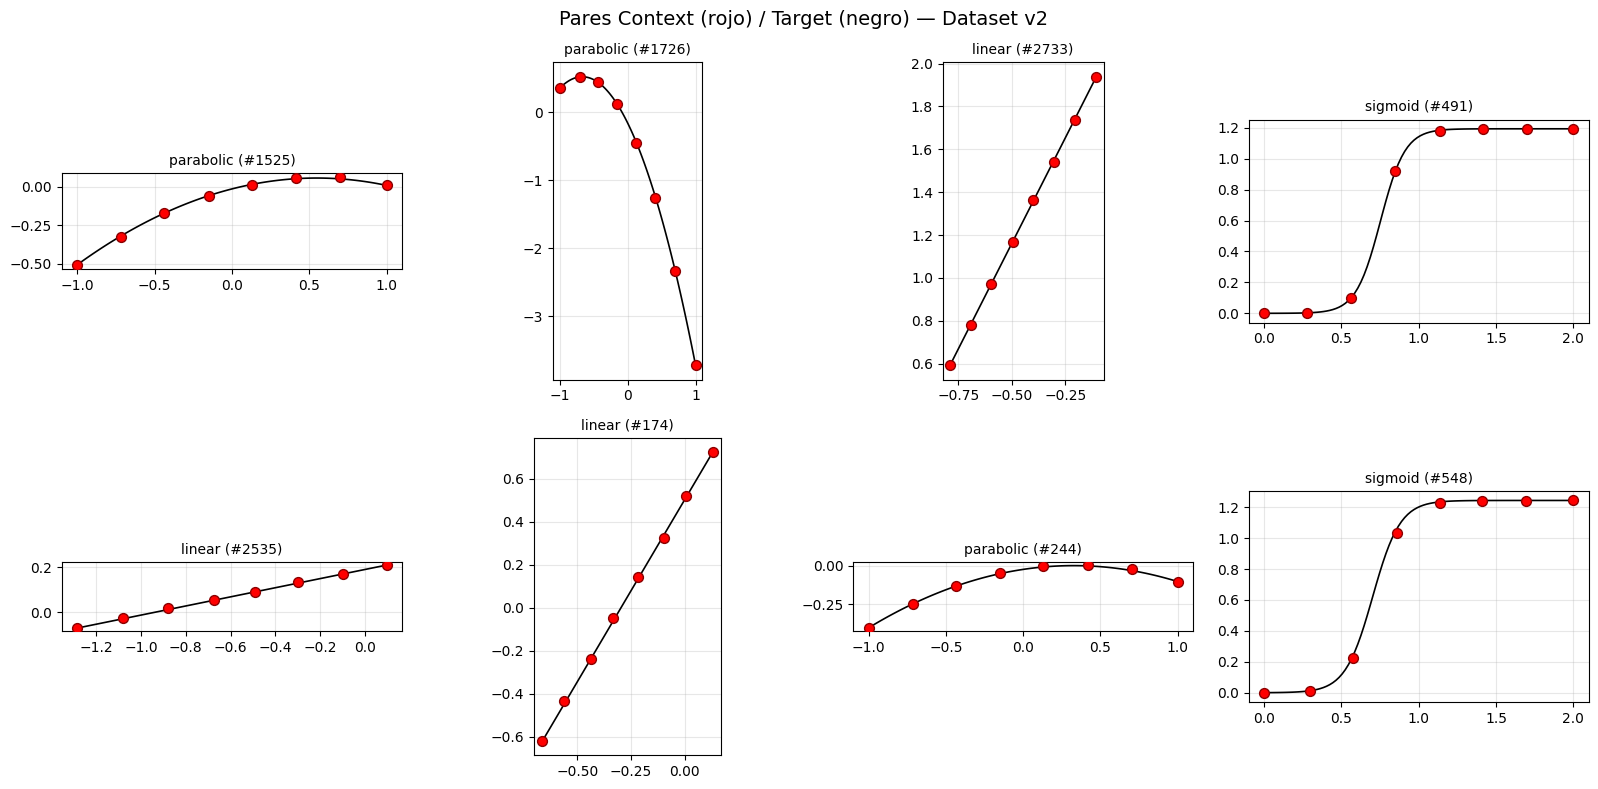

In [11]:
with h5py.File(FILENAME, 'r') as f:
    n = f.attrs['total_demos']
    indices = np.random.choice(n, size=min(8, n), replace=False)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        ax = axes[i]
        d = f[f'data/demo_{idx}']
        ctx = d['context'][:]
        tgt = d['target'][:]
        traj_type = d.attrs['type']
        
        ax.plot(tgt[:, 0], tgt[:, 1], 'k-', linewidth=1.2)
        ax.scatter(ctx[:, 0], ctx[:, 1], c='red', s=50,
                   edgecolors='darkred', linewidths=1, zorder=5)
        ax.set_title(f"{traj_type} (#{idx})", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
    
    plt.suptitle("Pares Context (rojo) / Target (negro) — Dataset v2", fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. Implicaciones para el pipeline

Este cambio en el dataset requiere ajustes en el notebook de entrenamiento
(`heterogeneous_graphs.ipynb`):

### `build_hetero_graph`
- Antes: `n_context == n_action` (ambos ~100 puntos).
- Ahora: `n_context` (~8) **<<** `n_action` (~100).
- Las aristas k-NN `context → action` seguirán funcionando, pero `k_neighbors`
  debe limitarse a `min(k_neighbors, n_context)` (ya se hacía).
- Las aristas secuenciales `context ↔ context` seguirán funcionando pero con
  solo ~7 aristas en vez de ~99.

### `InstantPolicyModel`
- Ya usa embeddings separados para `context` y `action` → **no requiere cambios**.
- La GNN heterogénea maneja automáticamente nodos de diferente cardinalidad.

### `generate_trajectory` (inferencia)
- Ahora el grafo de contexto en inferencia será un grafo con solo ~8 nodos
  `context` (los waypoints que definen la tarea).
- Esto es mucho más realista: "dado estos puntos de referencia, generá una
  trayectoria suave".

### Resumen del nuevo flujo:

```
Waypoints sparse (context)  →  GNN + Difusión  →  Trayectoria completa (action)
     (8 puntos)                                        (100 puntos)
```